# Bank Customer Churn Propensity Model:

**Problem Statement**:

The bank has compiled a database of five high-net-worth individuals, each maintaining a balance exceeding $1 million and holding an active membership. The objective is to assess the probabilistic likelihood of churn for 5 individuals aged 55 to 66 based on specific parameters.


In [0]:

## Installing and upgrading the required libraries:-
## Installing and upgrading the required libraries:-
%pip install --upgrade pip
%pip uninstall -y numpy
%pip install numpy==1.24
%pip install tensorflow
%pip install shap

DEPRECATION: Using the pkg_resources metadata backend is deprecated. pip 26.3 will enforce this behaviour change. A possible replacement is to use the default importlib.metadata backend, by unsetting the _PIP_USE_IMPORTLIB_METADATA environment variable. Discussion can be found at https://github.com/pypa/pip/issues/13317
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
DEPRECATION: Using the pkg_resources metadata backend is deprecated. pip 26.3 will enforce this behaviour change. A possible replacement is to use the default importlib.metadata backend, by unsetting the _PIP_USE_IMPORTLIB_METADATA environment variable. Discussion can be found at https://github.com/pypa/pip/issues/13317
Found existing installation: numpy 1.24.0
Uninstalling numpy-1.24.0:
  Successfully uninstalled numpy-1.24.0
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
D

In [0]:
%restart_python
# Important Libraries:-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
import tensorflow as TF

from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense



2025-04-28 23:43:39.692709: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-28 23:43:39.699427: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-28 23:43:39.717516: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745883819.745729    3984 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745883819.754206    3984 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745883819.775308    3984 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [0]:
#Integrating Azure blob storage with Databricks using SAS key:-
storage_account_name = 'bheeshmaproject'
container_name = 'databasestore'
file_name = 'Bank_Customers.csv'
# Accesing cleint access key
storage_account_access_key = '**********************************'  
file_type = 'csv'
file_location = 'wasbs://' + container_name + '@' + storage_account_name + '.blob.core.windows.net/' + file_name


In [0]:
# Importing spark session obejct:-
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()
# Creating the spark configeration with Azure Blob:-
spark.conf.set("fs.azure.account.key." + storage_account_name + ".blob.core.windows.net", storage_account_access_key)


In [0]:
# Reading the datbase:-
df = spark.read.format(file_type).option("header","true").option("inferSchema", "true").load(file_location) 


In [0]:
display(df)
# Insight: A value of 1 indicates that the customer has exited the bank (i.e., the customer has churned), whereas a value of 0 indicates that the customer has not exited the bank.

RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1,15634602,Hargrave,619,France,Female,42.0,2,0.0,1,1,1,101348.88,1
2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,France,Female,42.0,8,159660.8,3,1,0,113931.57,1
4,15701354,Boni,699,France,Female,39.0,1,0.0,2,0,0,93826.63,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,null,1,79084.1,0
6,15574012,Chu,645,Spain,Male,44.0,8,113755.78,2,1,0,149756.71,1
7,15592531,Bartlett,822,null,Male,50.0,7,0.0,2,1,1,10062.8,0
8,15656148,Obinna,376,Germany,Female,29.0,4,115046.74,4,1,0,119346.88,1
9,15792365,He,501,France,Male,44.0,4,142051.07,2,0,null,74940.5,0
10,15592389,H?,684,France,Male,null,2,134603.88,1,1,1,71725.73,0


**Model Application:**

Data Cleaning

In [0]:
# Function to load and clean the database:-
DF = df.toPandas() # Converting the Spark dataframe to Pandas dataframe
DF.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [0]:
# Chekcing for the missing values in the database:-
DF.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [0]:
# Droping the rows with null values in the database:-
DF_Filtered = DF.dropna()
DF_Filtered.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,6,15574012,Chu,645,Spain,Male,44.0,8,113755.78,2,1.0,0.0,149756.71,1


In [0]:
# Removing duplicate values from the database.
DF_Filtered = DF_Filtered.drop_duplicates()
DF_Filtered

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,6,15574012,Chu,645,Spain,Male,44.0,8,113755.78,2,1.0,0.0,149756.71,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39.0,5,0.00,2,1.0,0.0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35.0,10,57369.61,1,1.0,1.0,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36.0,7,0.00,1,0.0,1.0,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42.0,3,75075.31,2,1.0,0.0,92888.52,1


In [0]:
# Converting the categorical gender column into binary format.
Gender= {'Female':0,'Male':1}
DF_Filtered['Gender'] = DF_Filtered['Gender'].map(Gender)
DF_Filtered

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,0,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,0,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,0,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,0,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,6,15574012,Chu,645,Spain,1,44.0,8,113755.78,2,1.0,0.0,149756.71,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,1,39.0,5,0.00,2,1.0,0.0,96270.64,0
9996,9997,15569892,Johnstone,516,France,1,35.0,10,57369.61,1,1.0,1.0,101699.77,0
9997,9998,15584532,Liu,709,France,0,36.0,7,0.00,1,0.0,1.0,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,1,42.0,3,75075.31,2,1.0,0.0,92888.52,1


In [0]:
# Splitting the data into target and features. 
Y = DF_Filtered['Exited']
X = DF_Filtered.drop(['Exited','RowNumber','CustomerId','Surname','Geography'],axis=1)
print(Y)
print(X)

0        1
1        0
2        1
3        0
5        1
        ..
9995     0
9996     0
9997     1
9998     1
10000    0
Name: Exited, Length: 9996, dtype: int32
       CreditScore  Gender   Age  ...  HasCrCard  IsActiveMember  EstimatedSalary
0              619       0  42.0  ...        1.0             1.0        101348.88
1              608       0  41.0  ...        0.0             1.0        112542.58
2              502       0  42.0  ...        1.0             0.0        113931.57
3              699       0  39.0  ...        0.0             0.0         93826.63
5              645       1  44.0  ...        1.0             0.0        149756.71
...            ...     ...   ...  ...        ...             ...              ...
9995           771       1  39.0  ...        1.0             0.0         96270.64
9996           516       1  35.0  ...        1.0             1.0        101699.77
9997           709       0  36.0  ...        0.0             1.0         42085.58
9998           772

In [0]:
# Displaying the feature variables:-
X

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,42.0,2,0.00,1,1.0,1.0,101348.88
1,608,0,41.0,1,83807.86,1,0.0,1.0,112542.58
2,502,0,42.0,8,159660.80,3,1.0,0.0,113931.57
3,699,0,39.0,1,0.00,2,0.0,0.0,93826.63
5,645,1,44.0,8,113755.78,2,1.0,0.0,149756.71
...,...,...,...,...,...,...,...,...,...
9995,771,1,39.0,5,0.00,2,1.0,0.0,96270.64
9996,516,1,35.0,10,57369.61,1,1.0,1.0,101699.77
9997,709,0,36.0,7,0.00,1,0.0,1.0,42085.58
9998,772,1,42.0,3,75075.31,2,1.0,0.0,92888.52


In [0]:
from sklearn.preprocessing import MinMaxScaler
# Applying min-max scaling to the data. This is done to ensure that the values are within the range of 0 to 1.
# This ensures that the database feature with the large magnitude does not dominate the model output.
scaler = MinMaxScaler()
X_Scaled = scaler.fit_transform(X)
X_Scaled

array([[0.538     , 0.        , 0.32432432, ..., 1.        , 1.        ,
        0.50673489],
       [0.516     , 0.        , 0.31081081, ..., 0.        , 1.        ,
        0.56270874],
       [0.304     , 0.        , 0.32432432, ..., 1.        , 0.        ,
        0.56965435],
       ...,
       [0.718     , 0.        , 0.24324324, ..., 0.        , 1.        ,
        0.21039009],
       [0.844     , 1.        , 0.32432432, ..., 1.        , 0.        ,
        0.46442905],
       [0.884     , 0.        , 0.13513514, ..., 1.        , 0.        ,
        0.19091423]])

In [0]:
# Splitting the data into training and testing sets.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_Scaled, Y, test_size=0.3, random_state=42)

**Model Fine-Tuning (Feature Selection): SHAP Values**


We will be applying the technique of  SHAP values method to analyse the impact of database features on the targeted variable after the training the database model.

In [0]:
# Importing SHAP
import shap

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

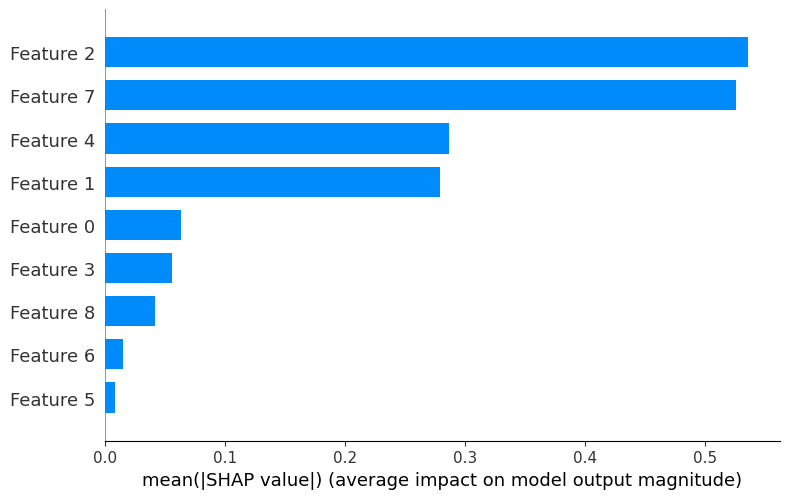

In [0]:
# Training the model: Logistic Regression
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)


# Calcaulating the SHAP values

Explainer = shap.LinearExplainer(logreg, X_train)
shap_values = Explainer.shap_values(X_train)

# Vizualising the SHAP values in beeswarms plot.
shap.summary_plot(shap_values, X_train, plot_type="bar")


%md
Feature Insights:

**Threshold Level: 0.1**

1) **Age (Feature 2)**: The Age feature has an average magnitude of 0.55, indicating the highest impact on the target variable. Therefore, it will be retained for further analysis.
2) **Membership Status (Feature 7)**: The membership status of customers has a magnitude of 0.5, making it the second most impactful feature on customer churn status after Age.
3) **Balance (Feature 4)**: The customer's account balance significantly impacts customer churn status, with a high magnitude.
4) **Gender (Feature 1)**: The Gender feature has a magnitude of 0.28, showing a notable impact on the target variable.

Features with an average impact magnitude lower than 0.1 will be excluded from further analysis.

**Model Application:**


In [0]:
# Independent variables:- Modifying and scaling our independent variables.
X_Modified = X[['Gender','Age','Balance','IsActiveMember']]
X_Scaled_Modified = scaler.fit_transform(X_Modified)
X_Scaled_Modified


array([[0.        , 0.32432432, 0.        , 1.        ],
       [0.        , 0.31081081, 0.33403148, 1.        ],
       [0.        , 0.32432432, 0.63635718, 0.        ],
       ...,
       [0.        , 0.24324324, 0.        , 1.        ],
       [1.        , 0.32432432, 0.29922631, 0.        ],
       [0.        , 0.13513514, 0.51870777, 0.        ]])

In [0]:
# Splitting our model into tranining and testing sets.
from sklearn.model_selection import train_test_split
X_train_Modified, X_test_Modified, y_train_Modified, y_test_Modified = train_test_split(X_Scaled_Modified, Y, test_size=0.3, random_state=42)

**Model Development:**

In [0]:
# Building the model:-
from sklearn.linear_model import LogisticRegression
Model = LogisticRegression()
Model.fit(X_train_Modified, y_train_Modified)


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

LogisticRegression()

In [0]:
# Predicting the customer churn using the trained and scaled dataset.
y_pred = Model.predict(X_test_Modified)
print(y_pred)
print(y_pred.shape)


[0 0 0 ... 0 0 1]
(2999,)


In [0]:
# Import the pandas library.
import pandas as pd
# Developing pandas dataframe with the predicted values with the actual values.
Predicted_DF = pd.DataFrame({'Actual': y_test_Modified, 'Predicted': y_pred})
Predicted_DF

,Actual,Predicted
1082,1,0
4340,0,0
8970,0,0
5460,0,0
2411,0,0
...,...,...
5583,0,0
1078,0,0
9303,0,0
3095,0,0


**Model Accuracy**:

In [0]:
# Calculating the accuracy of the model: Applying the confusion matrix.
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test_Modified, y_pred)



array([[2321,   68],
       [ 512,   98]])

**Insights:-**
- True Negative (TN): 2321
- False Positive (FP): 68
- False Negative (FN): 512
- True Positive (TP): 98

In [0]:
from sklearn.metrics import classification_report
print(classification_report(y_test_Modified, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      2389
           1       0.59      0.16      0.25       610

    accuracy                           0.81      2999
   macro avg       0.70      0.57      0.57      2999
weighted avg       0.77      0.81      0.76      2999



**Insights:-** Therefore, the model has an accuracy score of 81%.


**Problem -Statement:** Applying the model:-

Based on SHAP method, we have decided to move on with the customer's attributes that highly impact the customer's churn status. Which are :- ['Gender','Age','Balance','IsActiveMember'].


In [0]:
# Developing the model pipeline to automate the process of scaling and predicting the churn status.
from sklearn.pipeline import Pipeline

Model_Pipeline = Pipeline([('Scaler', scaler), ('Model', Model)])
Model_Pipeline = Model_Pipeline.fit(X_train_Modified, y_train_Modified)



Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

In [0]:
# Creating the pandas dataframe based on the given parameters.
Parameters = pd.DataFrame({'Gender':[1,0,0,1,1],'Age':[55,57,61,54,59],'Balance':[1000000,3000000,4300000,4100000,3200000],'IsActiveMember':[1,1,1,1,1]}
                          ,index = [0,1,2,3,4])
Input = Parameters[['Gender','Age','Balance','IsActiveMember']]

# Applying the model Pipeline for streamlining the model application process.
OutPut = Model_Pipeline.predict(Input)
OutPut = pd.DataFrame({'Cient Info':list(Input.values),'Churn Status':OutPut})
OutPut['Churn Status'] = OutPut['Churn Status'].replace({0:'Not Likely to be Churned',1:' Like To Be Churned'})
OutPut

/databricks/python/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


,Cient Info,Churn Status
0,"[1, 55, 1000000, 1]",Like To Be Churned
1,"[0, 57, 3000000, 1]",Like To Be Churned
2,"[0, 61, 4300000, 1]",Like To Be Churned
3,"[1, 54, 4100000, 1]",Like To Be Churned
4,"[1, 59, 3200000, 1]",Like To Be Churned


Conclusion:-

The analysis reveals that all five High Net-Worth Individual (HNI) clients currently associated with the bank are exhibiting behavioral patterns and transactional signals indicative of a heightened risk of attrition. These clients are actively engaging with competing financial institutions and demonstrating a potential disengagement with the bank’s premium offerings, suggesting a future inclination to switch their banking relationships. Given the strategic importance of HNI clients, it is important to initiate immediate retention strategies, including personalized outreach, relationship management interventions, and tailored financial solutions to reinforce client loyalty and mitigate the risk of churn.